In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import random
from faker import Faker
import numpy as np

In [3]:
fake = Faker()

In [4]:
num_records = 500
data = []

for _ in range(num_records):
    date = fake.date_between(start_date='-2y', end_date='today')
    store = random.randint(1, 10)
    item = random.randint(100, 200)
    sales = random.randint(1, 50)
    region = random.choice(['North', 'South', 'East', 'West'])

    data.append([date, store, item, sales, region])


In [5]:
df = pd.DataFrame(data, columns=['Date', 'Store', 'Item', 'Sales', 'Region'])
df.head()

,Date,Store,Item,Sales,Region
0,2025-06-17,10,150,45,West
1,2024-09-24,3,175,16,South
2,2024-11-14,4,101,36,West
3,2025-08-13,1,101,1,West
4,2024-10-15,6,121,20,East


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.isnull().sum()
df.drop_duplicates(inplace=True)
df = df.sort_values('Date')
df.head()

,Date,Store,Item,Sales,Region
304,2024-04-07,6,139,41,North
25,2024-04-07,10,182,44,South
209,2024-04-09,3,127,24,East
134,2024-04-09,10,101,47,North
495,2024-04-09,9,142,34,North


In [7]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
store_sales = df.groupby('Store')['Sales'].sum()
store_sales

Total Sales: 12174
Average Sales: 24.348


,Sales
Store,
1,1382
2,1339
3,996
4,1350
5,1123
6,1205
7,1121
8,1251
9,1120


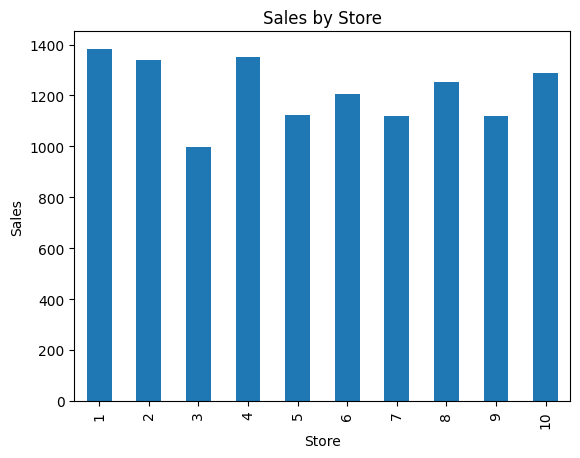

In [8]:
import matplotlib.pyplot as plt
store_sales.plot(kind='bar')
plt.title("Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales")
plt.show()